In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("/home/vivek/Desktop/apple_products.csv")
print(df)
df.head()

             Date  Platform Product_Category                   Model_Name  \
0      2020-09-19  Flipkart            Watch  Apple Watch Series 6 (44mm)   
1      2020-09-20  Flipkart            Watch  Apple Watch Series 6 (44mm)   
2      2020-09-23    Amazon            Watch  Apple Watch Series 6 (44mm)   
3      2020-09-23    Amazon            Watch  Apple Watch Series 6 (44mm)   
4      2020-09-24    Amazon            Watch  Apple Watch Series 6 (44mm)   
...           ...       ...              ...                          ...   
79995  2026-07-31  Flipkart           iPhone              iPhone 17 128GB   
79996  2026-07-31  Flipkart           iPhone              iPhone 17 128GB   
79997  2026-07-31    Amazon           iPhone              iPhone 17 128GB   
79998  2026-07-31  Flipkart           iPhone              iPhone 17 128GB   
79999  2026-07-31  Flipkart           iPhone              iPhone 17 128GB   

                 Condition  Launch_Price_USD  Launch_Price_INR  \
0        

,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count
0,2020-09-19,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,435.81,43322.41,-1.6,NaN,In Stock,4.7,40
1,2020-09-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.49,42320.43,-1.7,NaN,Out of Stock,4.6,84
2,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,422.73,40879.36,1.5,NaN,In Stock,4.4,110
3,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,425.00,42008.70,0.9,NaN,In Stock,4.8,111
4,2020-09-24,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.22,41984.28,-1.7,NaN,In Stock,4.7,35


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               80000 non-null  str    
 1   Platform           80000 non-null  str    
 2   Product_Category   80000 non-null  str    
 3   Model_Name         80000 non-null  str    
 4   Condition          80000 non-null  str    
 5   Launch_Price_USD   80000 non-null  int64  
 6   Launch_Price_INR   80000 non-null  int64  
 7   Current_Price_USD  80000 non-null  float64
 8   Current_Price_INR  80000 non-null  float64
 9   Discount_Pct       80000 non-null  float64
 10  Sale_Event         6649 non-null   str    
 11  Stock_Status       80000 non-null  str    
 12  Rating             80000 non-null  float64
 13  Reviews_Count      80000 non-null  int64  
dtypes: float64(4), int64(3), str(7)
memory usage: 8.5 MB


In [3]:
df.isnull().sum()

Date                     0
Platform                 0
Product_Category         0
Model_Name               0
Condition                0
Launch_Price_USD         0
Launch_Price_INR         0
Current_Price_USD        0
Current_Price_INR        0
Discount_Pct             0
Sale_Event           73351
Stock_Status             0
Rating                   0
Reviews_Count            0
dtype: int64

In [4]:
df["Sale_Event"]=df["Sale_Event"].fillna("unknown",inplace=True)

/tmp/ipykernel_2886/741350981.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Sale_Event"]=df["Sale_Event"].fillna("unknown",inplace=True)


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Rating,Reviews_Count
count,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000
mean,963.959125,94467.994250,782.769855,74628.342439,21.418826,4.450099,2405.995925
std,470.086413,46068.468464,461.673970,45117.872172,16.697310,0.269782,1973.630852
min,329.000000,32242.000000,109.930000,9157.680000,-2.000000,3.800000,10.000000
25%,599.000000,58702.000000,432.930000,41686.835000,6.700000,4.300000,896.000000
50%,799.000000,78302.000000,699.740000,67324.020000,21.300000,4.400000,1893.500000
75%,1199.000000,117502.000000,989.112500,96568.117500,36.800000,4.700000,3383.000000
max,1999.000000,195902.000000,2038.970000,203668.710000,73.100000,4.900000,11526.000000


1. FIND THE AVERAGE CURRENT PRICE OF APPLE PRODUCTS FOR EACH PRODUCTS CATEGORY.

In [7]:
avg_priceINR=df.groupby('Product_Category')["Current_Price_INR"].mean()
print(avg_priceINR)

avg_priceUSD=df.groupby('Product_Category')["Current_Price_USD"].mean()
print(avg_priceUSD)

Product_Category
Mac       131766.935548
Watch      37983.284920
iPad       54633.857522
iPhone     72370.861505
Name: Current_Price_INR, dtype: float64
Product_Category
Mac       1382.489812
Watch      398.638561
iPad       573.083382
iPhone     758.674718
Name: Current_Price_USD, dtype: float64


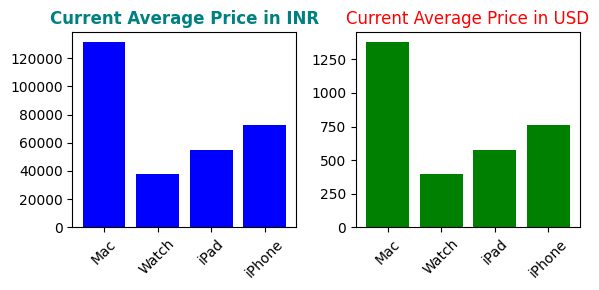

In [8]:
plt.figure(figsize=(6,3))

# First Plot - INR
plt.subplot(1,2,1)
plt.bar(avg_priceINR.index, avg_priceINR.values, color='blue')
plt.title("Current Average Price in INR",color="Teal",fontweight="bold")
plt.xticks(rotation=45)

# Second Plot - USD
plt.subplot(1,2,2)
plt.bar(avg_priceUSD.index, avg_priceUSD.values, color='green')
plt.title("Current Average Price in USD",color="Red")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


2. IDENTIFY THE TOP 10 MOST EXPENSIVE APPLE PRODUCTS

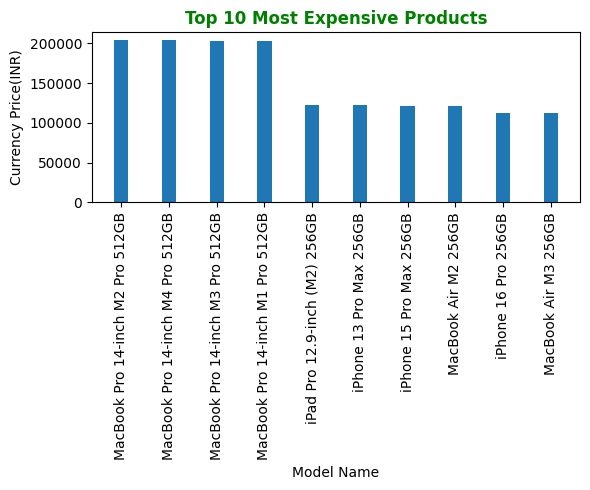

In [30]:
top10=(df.sort_values(by="Current_Price_INR",ascending=False).drop_duplicates(subset="Model_Name").head(10))
plt.figure(figsize=(6,5))
plt.bar(top10["Model_Name"],top10["Current_Price_INR"],width=0.3)
plt.title("Top 10 Most Expensive Products",fontweight="bold",color="green")
plt.xlabel("Model Name")
plt.ylabel("Currency Price(INR)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

3. COMPARE THE AVERAGE DISCOUNT PERCENTAGE OFFERED BY AMAZON FLIPKART .

In [10]:
avg=df.groupby('Platform')["Discount_Pct"].mean()
print(avg)

Platform
Amazon      21.515399
Flipkart    21.322461
Name: Discount_Pct, dtype: float64


/tmp/ipykernel_2886/2245781716.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg,palette="muted")


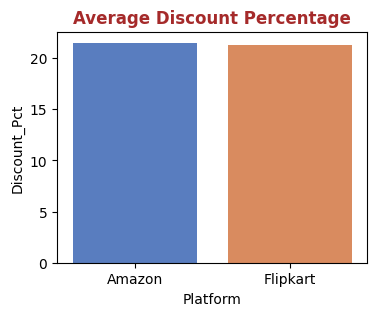

In [11]:
plt.figure(figsize=(4,3))
sns.barplot(data=avg,palette="muted")
plt.title("Average Discount Percentage",fontweight="bold",color="brown")
plt.show()

4. FIND THE NUMBER OF PRODUCTS THAT ARE IN STOCK AND OUT OF STOCK 

In [12]:
print(df['Stock_Status'].value_counts())

Stock_Status
In Stock        55034
Out of Stock    13475
Low Stock       11491
Name: count, dtype: int64


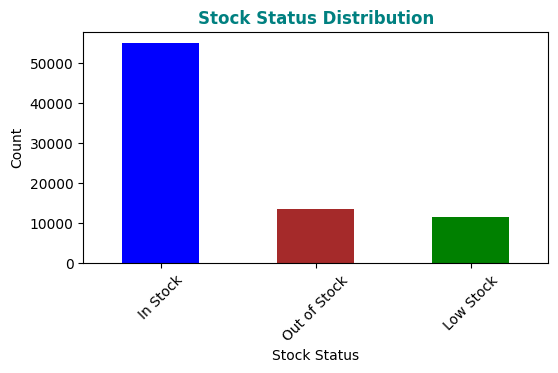

In [13]:
# Count values
stock_count = df['Stock_Status'].value_counts()

plt.figure(figsize=(6,3))
stock_count.plot(kind='bar', color=["blue","Brown","green"])

plt.title('Stock Status Distribution',color="Teal",fontweight="bold")
plt.xlabel('Stock Status')
plt.ylabel('Count')

plt.xticks(rotation=45)
plt.show()

5. ANALYZE THE YEARLY TREND OF AVERAGE PRODUCT PRICES FROM 2010 TO 2026

In [14]:
df["Date"]=pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year

In [15]:
date_avg=df.groupby('Year')["Current_Price_INR"].mean()
print(date_avg)

Year
2020    63092.654655
2021    68772.268401
2022    70773.903729
2023    75730.290132
2024    76432.901295
2025    76231.651824
2026    72477.822866
Name: Current_Price_INR, dtype: float64


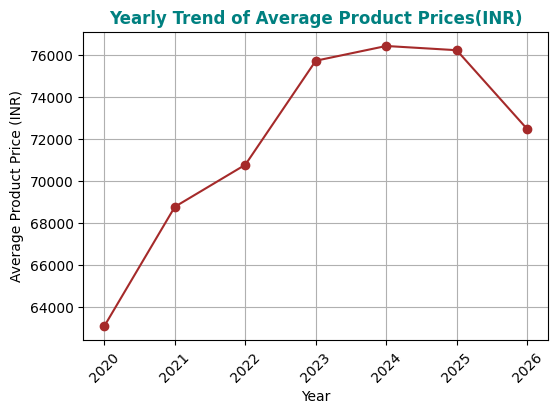

In [16]:
plt.figure(figsize=(6,4))

plt.plot(date_avg.index, date_avg.values,
         marker='o', color='brown')

plt.title('Yearly Trend of Average Product Prices(INR)',color="Teal",fontweight="bold")
plt.xlabel('Year')
plt.ylabel('Average Product Price (INR)')

plt.grid(True)
plt.xticks(rotation=45)

plt.show()

6. FIND THE AVERAGE CUSTOMER RATING FOR EACH PRODUCT CATEGORY.

In [31]:
rate=df.groupby('Product_Category')["Rating"].mean().sort_values(ascending=False)
print(rate)

Product_Category
iPhone    4.451240
Mac       4.450461
iPad      4.449916
Watch     4.448066
Name: Rating, dtype: float64


/tmp/ipykernel_2886/3487094821.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rate,palette="mako")


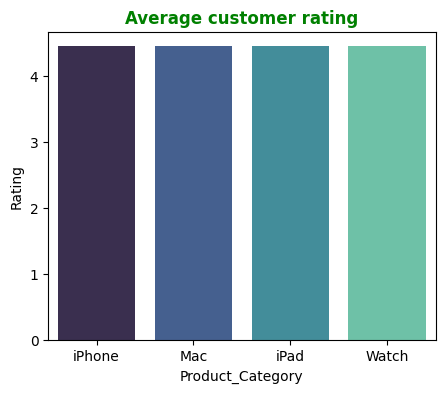

In [32]:
plt.figure(figsize=(5,4))
sns.barplot(data=rate,palette="mako")
plt.title("Average customer rating",fontweight="bold",color="green")
plt.show()

7. Determine the which sales event provides the highest average disvount percentage.

In [19]:
avg_discount = df.groupby('Sale_Event')['Discount_Pct'].mean().sort_values(ascending=False)

print(avg_discount)

Sale_Event
Big Billion Days         37.023686
Prime Day                34.435734
Great Indian Festival    33.446077
Black Friday             31.462155
unknown                  20.304699
Name: Discount_Pct, dtype: float64


/tmp/ipykernel_2886/2774060911.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


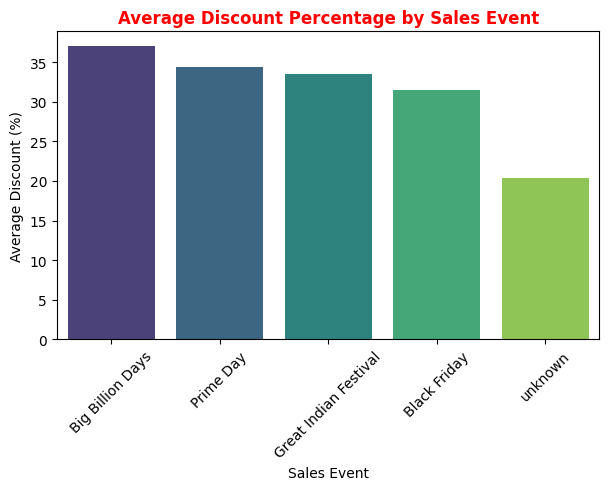

In [20]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=avg_discount,
    palette='viridis'
)

plt.title('Average Discount Percentage by Sales Event',fontweight="bold",color="red")
plt.xlabel('Sales Event')
plt.ylabel('Average Discount (%)')
plt.xticks(rotation=45)
plt.show()

8. ANALYZE WHETHER HIGHER DISCOUNTS LEAD TO BETTER CUSTOMER RATINGS.

Correlation between Discount and Rating: -0.31025721562654696


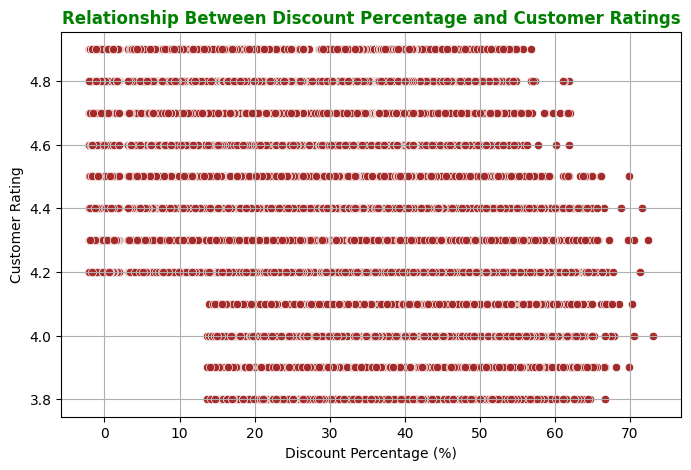

In [21]:
correlation = df['Discount_Pct'].corr(df['Rating'])

print("Correlation between Discount and Rating:", correlation)

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Discount_Pct',
    y='Rating',
    color='brown'
)

plt.title('Relationship Between Discount Percentage and Customer Ratings',color="green",fontweight="bold")
plt.xlabel('Discount Percentage (%)')
plt.ylabel('Customer Rating')

plt.grid(True)
plt.show()

9. COMPARE AMAZON AND FLIPKART BASED ON AVERAGE PRICE, AVERAGE DISCOUNT, AVERAGE RATING AND TOTAL PRODUCTS LISTED.

In [22]:
platform_compare = df.groupby('Platform').agg(
    Average_Price=('Current_Price_USD', 'mean'),
    Average_Discount=('Discount_Pct', 'mean'),
    Average_Rating=('Rating', 'mean'),
    Total_Products=('Model_Name', 'count')
).reset_index()

print(platform_compare)

   Platform  Average_Price  Average_Discount  Average_Rating  Total_Products
0    Amazon     783.968025         21.515399        4.450802           39957
1  Flipkart     781.574259         21.322461        4.449397           40043


/tmp/ipykernel_2886/4240767664.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_2886/4240767664.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_2886/4240767664.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_2886/4240767664.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


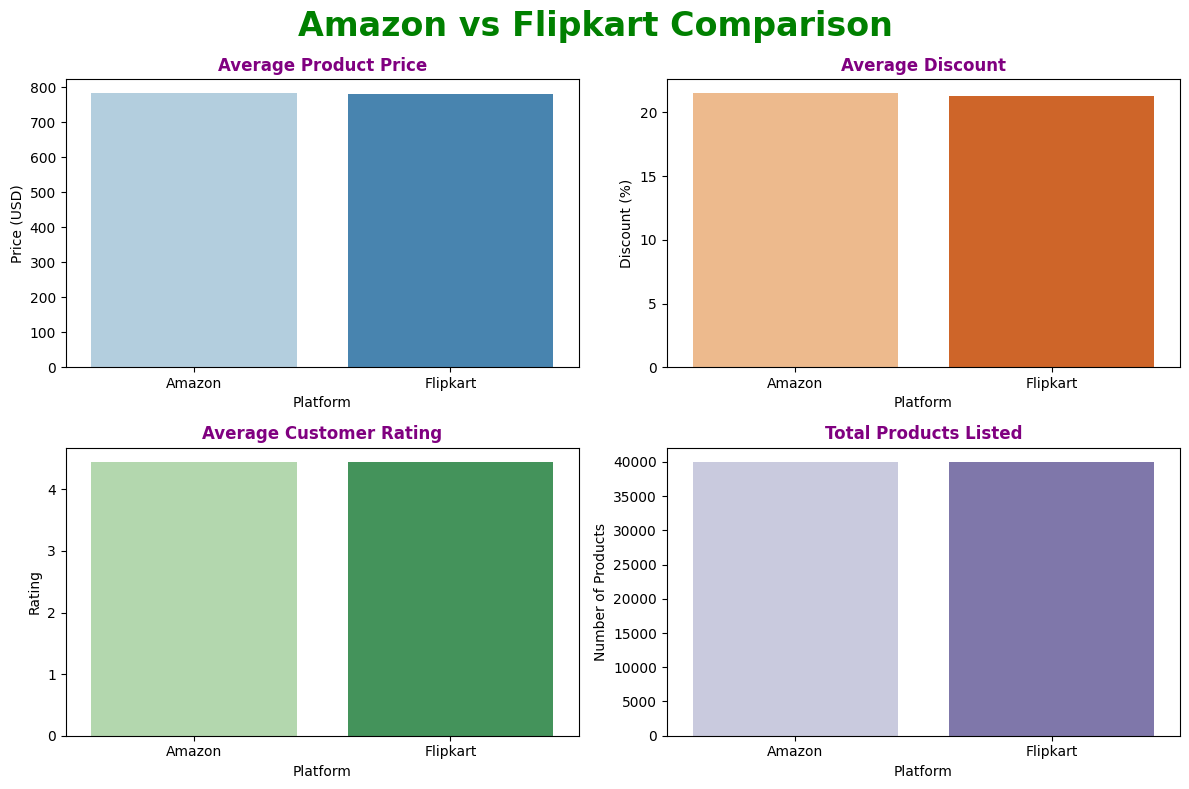

In [23]:
plt.figure(figsize=(12,8))
# 1. Average Price
plt.subplot(2,2,1)
sns.barplot(
    data=platform_compare,
    x='Platform',
    y='Average_Price',
    palette='Blues'
)
plt.title('Average Product Price',fontweight="bold",color="Purple")
plt.xlabel('Platform')
plt.ylabel('Price (USD)')

# 2. Average Discount
plt.subplot(2,2,2)
sns.barplot(
    data=platform_compare,
    x='Platform',
    y='Average_Discount',
    palette='Oranges'
)
plt.title('Average Discount',fontweight="bold",color="Purple")
plt.xlabel('Platform')
plt.ylabel('Discount (%)')

# 3. Average Rating
plt.subplot(2,2,3)
sns.barplot(
    data=platform_compare,
    x='Platform',
    y='Average_Rating',
    palette='Greens'
)
plt.title('Average Customer Rating',fontweight="bold",color="Purple")
plt.xlabel('Platform')
plt.ylabel('Rating')


# 4. Total Products
plt.subplot(2,2,4)
sns.barplot(
    data=platform_compare,
    x='Platform',
    y='Total_Products',
    palette='Purples'
)
plt.title('Total Products Listed',fontweight="bold",color="Purple")
plt.xlabel('Platform')
plt.ylabel('Number of Products')

plt.suptitle('Amazon vs Flipkart Comparison',fontsize=24, fontweight="bold",color="Green")
plt.tight_layout()
plt.show()